# OpenClassrooms - parcours Data Analyst Business Intelligence - P8

# Milestone 1 - Analyse des données

Dans cette partie nous allons analyser le jeu de données que nous avons à notre disposition. Notre objectif est de comprendre les relations entre les variables, et surtout, celles qui influent sur le prix des transactions immobilières. Grâce à ce travail, nous pourrons ne conserver que les variables qui seront utiles à l'apprentissage de notre algorithme.

## 1.Type des données

La première étape à réaliser est d'importer les données dans le notebook et d'opérer des transformations sur les variables si celles-ci s'imposent (exemple : nettoyage ou changement de type des variables, etc.).

In [1]:
#On importe les librairies que nous utiliserons pour traiter les données et les visualiser
import pandas as pd, numpy as np, matplotlib as mp
# N'oubliez pas d'avoir installé les librairies pandas, numpy et matplotlib via la commande pip

In [2]:
#On importe les données dans un dataframe
df = pd.read_excel(r"C:\Users\thoma\OneDrive\Bureau\OPENCLASSROOM\Livrables\Projet_8 - Réalisez une analyse de données en Python\historique_immobilier_paris_2017_2021_vdef2.xlsx")

In [3]:
#Pour éviter l'affichage en valeur scientifique
pd.options.display.float_format = lambda x: f"{x:,.2f}".replace(",", " ")

Attention, si l'opération ci-dessus ne marche pas, il se peut que le package "openpyxl" ne soit pas présent sur votre ordinateur. Si c'est le cas vous pouvez l'installer en éxécutant la commande : pip install openpyxl ou conda install openpyxl.

In [4]:
#On vérifie que le type des données attribué par pandas est cohérent
df.head(5)

,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle
0,2017-01-03,550 559.68,8,RUE DES COUTURES SAINT GERVAIS,75003,Paris 3e Arrondissement,2,Appartement,50
1,2017-01-12,1 576 492.46,32,AV MARCEAU,75008,Paris 8e Arrondissement,2,Appartement,163
2,2017-01-10,657 757.36,52,RUE DU FAUBOURG SAINT HONORE,75008,Paris 8e Arrondissement,2,Appartement,66
3,2017-01-10,250 086.82,64,RUE DU VERTBOIS,75003,Paris 3e Arrondissement,2,Appartement,22
4,2017-01-13,176 266.71,25,RUE DES LAVANDIERES STE OPPORT,75001,Paris 1er Arrondissement,2,Appartement,15


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26196 entries, 0 to 26195
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mutation     26196 non-null  datetime64[ns]
 1   valeur_fonciere   26196 non-null  float64       
 2   adresse_numero    26196 non-null  int64         
 3   adresse_nom_voie  26196 non-null  object        
 4   code_postal       26196 non-null  int64         
 5   nom_commune       26196 non-null  object        
 6   code_type_local   26196 non-null  int64         
 7   type_local        26196 non-null  object        
 8   surface_reelle    26196 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 1.8+ MB


### 2. Regardons les différents types de biens immobiliers que nous avons dans nos données :

## print("La liste des différents types de biens immobiliers que nous avons dans les données est :"


In [6]:
print("La liste des différents types de biens immobiliers que nous avons dans les données est :",df["type_local"].unique())

La liste des différents types de biens immobiliers que nous avons dans les données est : ['Appartement' 'Local industriel. commercial ou assimilé']


### 3. Nombre de transactions

On observe qu'il y a 2 types de biens, et que leurs codes types sont 2 et 4. 

In [7]:
#On verifie le nombre de transactions que nous avons dans notre dataframe
print("le nombre de transactions dans les données est", df["type_local"].shape[0])
print("le nombre de transactions pour les appartements dans les données est", df[df["type_local"]=="Appartement"].shape[0])
print("le nombre de transactions pour les locaux commerciaux dans les données est",df[df["code_type_local"]==4].shape[0])

le nombre de transactions dans les données est 26196
le nombre de transactions pour les appartements dans les données est 24353
le nombre de transactions pour les locaux commerciaux dans les données est 1843


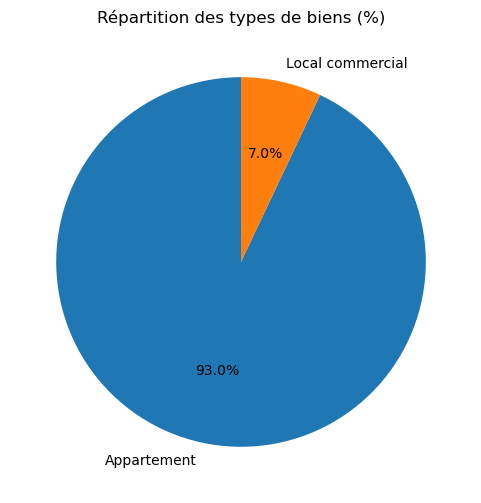

In [8]:

import matplotlib.pyplot as plt
proportions = df["type_local"].value_counts(normalize=True) * 100
proportions.index = ["Appartement", "Local commercial"]
plt.figure(figsize=(6,6))
proportions.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Répartition des types de biens (%)")

plt.show()

### 4. interval de l'historique des données

In [9]:
#On vérifie également la plage de l'historique disponible
print('la première date de transaction dans les données est le ?',df["date_mutation"].min())
print('la dernière date de transaction dans les données est le ?',df["date_mutation"].max())

la première date de transaction dans les données est le ? 2017-01-02 00:00:00
la dernière date de transaction dans les données est le ? 2021-12-31 00:00:00


Maintenant nous allons analyser les données historiques pour les 2 différents types de biens immobiliers en essayant d'identifier les relations entre les variables. Mais avant cela, il nous faudra pouvoir comparer les biens entre eux, et pour cela nous allons créer une colonne du prix au metre carré.

## Commençons à analyser les données

In [10]:
# Calcul de la colonne
df["prix_m2"] = df["valeur_fonciere"] / df["surface_reelle"]
df.head()

,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle,prix_m2
0,2017-01-03,550 559.68,8,RUE DES COUTURES SAINT GERVAIS,75003,Paris 3e Arrondissement,2,Appartement,50,11 011.19
1,2017-01-12,1 576 492.46,32,AV MARCEAU,75008,Paris 8e Arrondissement,2,Appartement,163,9 671.73
2,2017-01-10,657 757.36,52,RUE DU FAUBOURG SAINT HONORE,75008,Paris 8e Arrondissement,2,Appartement,66,9 966.02
3,2017-01-10,250 086.82,64,RUE DU VERTBOIS,75003,Paris 3e Arrondissement,2,Appartement,22,11 367.58
4,2017-01-13,176 266.71,25,RUE DES LAVANDIERES STE OPPORT,75001,Paris 1er Arrondissement,2,Appartement,15,11 751.11


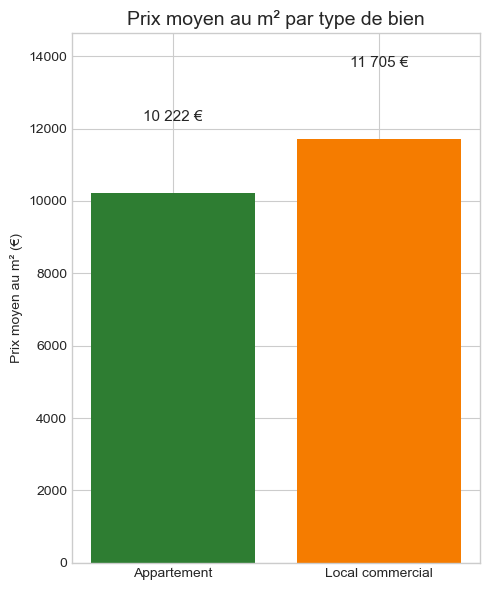

In [11]:
prix_moyens = df.groupby("type_local")["prix_m2"].mean()
prix_moyens.index = ["Appartement", "Local commercial"]

plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(5,6))

bars = plt.bar(
    prix_moyens.index,
    prix_moyens.values,
    color=["#2E7D32", "#F57C00"]
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 2000,
        f"{yval:,.0f}".replace(",", " ") + " €",
        ha='center',
        fontsize=11
    )

plt.title("Prix moyen au m² par type de bien", fontsize=14)
plt.ylabel("Prix moyen au m² (€)")
plt.ylim(0, prix_moyens.max() * 1.25)

plt.tight_layout()
plt.show()

Maintenant, analysons les appartements.

### 5. Evolution du prix au metre carré des appartements dans Paris

In [12]:
df_appartements = df[df["code_type_local"] == 2].copy()
df_appartements.info()



<class 'pandas.core.frame.DataFrame'>
Index: 24353 entries, 0 to 26195
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mutation     24353 non-null  datetime64[ns]
 1   valeur_fonciere   24353 non-null  float64       
 2   adresse_numero    24353 non-null  int64         
 3   adresse_nom_voie  24353 non-null  object        
 4   code_postal       24353 non-null  int64         
 5   nom_commune       24353 non-null  object        
 6   code_type_local   24353 non-null  int64         
 7   type_local        24353 non-null  object        
 8   surface_reelle    24353 non-null  int64         
 9   prix_m2           24353 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 2.0+ MB


In [13]:
df_appartements.columns

Index(['date_mutation', 'valeur_fonciere', 'adresse_numero',
       'adresse_nom_voie', 'code_postal', 'nom_commune', 'code_type_local',
       'type_local', 'surface_reelle', 'prix_m2'],
      dtype='object')

In [14]:
df_appartements.head(5)

,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle,prix_m2
0,2017-01-03,550 559.68,8,RUE DES COUTURES SAINT GERVAIS,75003,Paris 3e Arrondissement,2,Appartement,50,11 011.19
1,2017-01-12,1 576 492.46,32,AV MARCEAU,75008,Paris 8e Arrondissement,2,Appartement,163,9 671.73
2,2017-01-10,657 757.36,52,RUE DU FAUBOURG SAINT HONORE,75008,Paris 8e Arrondissement,2,Appartement,66,9 966.02
3,2017-01-10,250 086.82,64,RUE DU VERTBOIS,75003,Paris 3e Arrondissement,2,Appartement,22,11 367.58
4,2017-01-13,176 266.71,25,RUE DES LAVANDIERES STE OPPORT,75001,Paris 1er Arrondissement,2,Appartement,15,11 751.11


In [15]:
#Préparons un dataframe en regroupant les prix moyens de ventes des appartements par année avec la surface moyenne associée
df_appartements["annee"] = df_appartements["date_mutation"].dt.year

df_prix_surface = df_appartements.groupby("annee").agg({
    "valeur_fonciere": "mean",
    "surface_reelle": "mean",
    "prix_m2": "mean"})

df_prix_surface

,valeur_fonciere,surface_reelle,prix_m2
annee,,,
2017,427 963.24,44.63,9 492.86
2018,448 055.76,44.27,10 031.40
2019,461 950.06,43.36,10 562.71
2020,462 383.25,42.90,10 674.87
2021,458 771.51,43.48,10 455.60


On constate sur la moyenne des prix de vente des appartements à Paris que ? <br>
Nous allons créer un graphique pour mieux le visualiser.

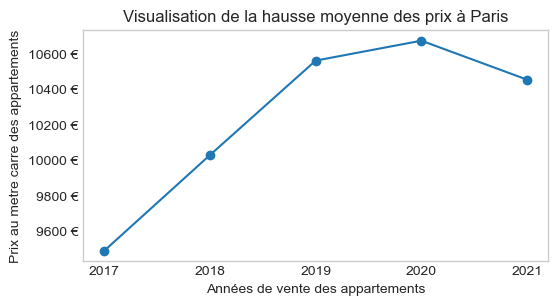

In [16]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.figure(figsize=(6,3))
#plt.plot(['2017','2018','2019','2020','2021'])
plt.plot(df_prix_surface.index.astype(str), df_prix_surface["prix_m2"], marker="o")
plt.xlabel('Années de vente des appartements')
plt.ylabel('Prix au metre carre des appartements')
formatter = ticker.FormatStrFormatter('%d €')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Visualisation de la hausse moyenne des prix à Paris')
plt.show()

### 6. Différences de prix au metre carré entre les arrondissements

Maintenant nous allons chercher à afficher l'évolution des prix par arrondissement. Vérifions la liste des arrondissements que nous avons dans nos données. Normalement à Paris nous avons 20 codes postaux différents, 1 par arrondissement allant de 75001 à 75020.

In [17]:
#Liste des codes postaux dans nos données.
df_appartements[
    ["nom_commune","code_postal"]
    ].drop_duplicates().sort_values("code_postal").reset_index(drop=True)

,nom_commune,code_postal
0,Paris 1er Arrondissement,75001
1,Paris 2e Arrondissement,75002
2,Paris 3e Arrondissement,75003
3,Paris 4e Arrondissement,75004
4,Paris 5e Arrondissement,75005
5,Paris 6e Arrondissement,75006
6,Paris 7e Arrondissement,75007
7,Paris 8e Arrondissement,75008
8,Paris 9e Arrondissement,75009
9,Paris 10e Arrondissement,75010


In [18]:
#Créeons un dataframe pour une deuxième visualisation avec l'evolution des prix par arrondissement
df_evolution_arr = df_appartements.groupby(["code_postal","annee"])["prix_m2"].mean().reset_index()
df_evolution_arr

,code_postal,annee,prix_m2
0,75001,2017,11 762.71
1,75001,2018,12 621.23
2,75001,2019,13 269.26
3,75001,2020,13 405.99
4,75001,2021,13 379.50
...,...,...,...
95,75020,2017,7 886.02
96,75020,2018,8 485.16
97,75020,2019,9 093.99
98,75020,2020,9 329.31


In [19]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix au metre carré dans le premier arrondissement
df_evolution_arr["annee"] = df_evolution_arr["annee"].astype(int) # les années apparaissent avec une décimale, je les converti en integer)
df_75001 = df_evolution_arr[df_evolution_arr["code_postal"] == 75001] # j'isole le premier arrondissement
df_75001.info()



<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   code_postal  5 non-null      int64  
 1   annee        5 non-null      int64  
 2   prix_m2      5 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 160.0 bytes


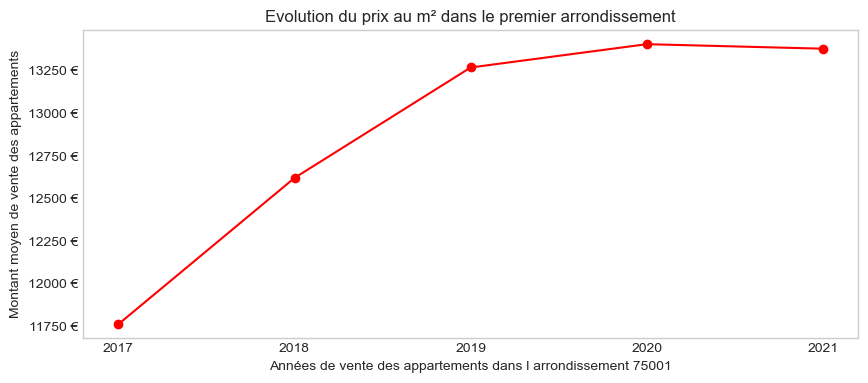

In [20]:
plt.figure(figsize=(10,4))
plt.plot(df_75001["annee"], df_75001["prix_m2"], marker="o",color='red')
plt.xticks(df_75001["annee"]) #force les années à apparaitre sans décimal
plt.xlabel('Années de vente des appartements dans l arrondissement 75001')
plt.ylabel('Montant moyen de vente des appartements')
formatter = ticker.FormatStrFormatter('%d €')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution du prix au m² dans le premier arrondissement')
plt.show()

Nous allons ajouter à cette visualisation tous les autres arrondissement avec une couleur différente.

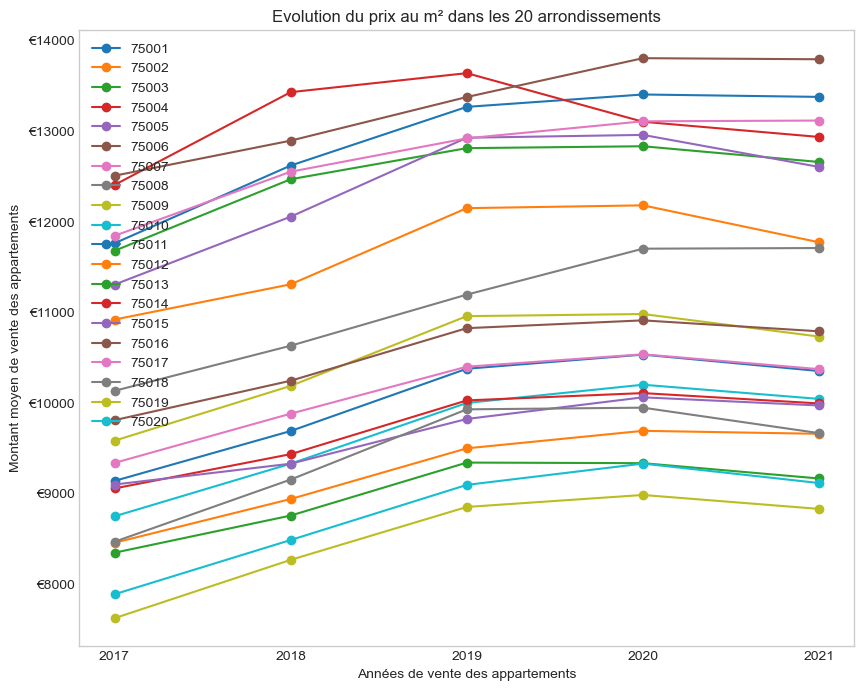

In [21]:
#On affiche l'évolution du prix au m² par arrondissement dans Paris
#On affiche l'évolution du prix au m² par arrondissement dans Paris
plt.figure(figsize=(10,8))
interval_historique=['2017','2018','2019','2020','2021']

for cp in sorted(df_evolution_arr["code_postal"].unique()):
    subset = df_evolution_arr[df_evolution_arr["code_postal"] == cp]
    plt.plot(
        subset["annee"].astype(str),
        subset["prix_m2"],
        marker="o",
        label=str(cp)
    )

plt.xlabel('Années de vente des appartements')
plt.ylabel('Montant moyen de vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution du prix au m² dans les 20 arrondissements')
plt.legend(loc='upper left')
plt.show()

# On observe que globalement que l'évolution des prix est la même pour tous les arrondissements.

### 7. Prix au metre carré par transaction dans un arrondissement

In [22]:
#Vérifions le nombre de transaction dans le 6ème car le prix semble élevé
nb_transactions_75006 = df_appartements[df_appartements["code_postal"] == 75006].shape[0]
nb_transactions_75006

709

On constate que ?
... 709 transactions ont été réalisées pour les appartements dans le 6ème arrondissement.

Affichons l'historique des transactions pour visualiser la dispersion des données :

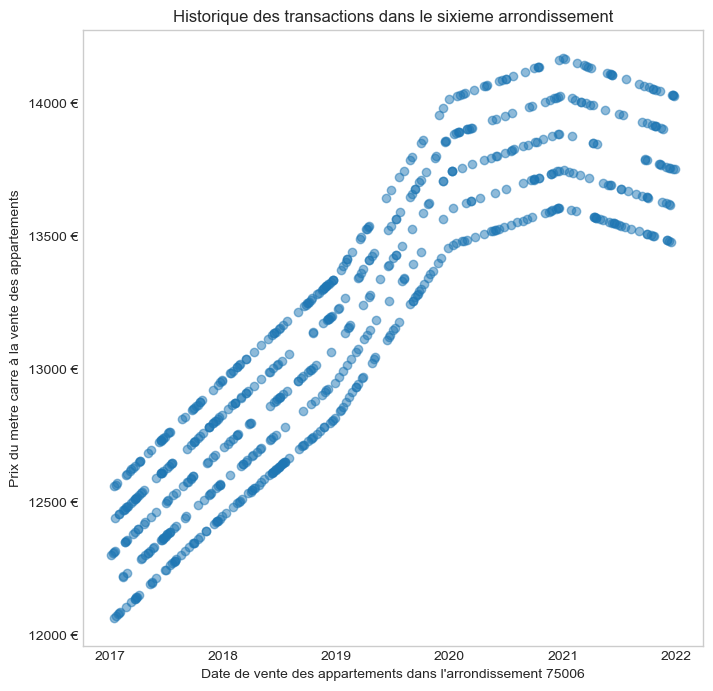

In [23]:
plt.figure(figsize=(8,8))
#Insérer ci-dessous le scatter plot
subset = df_appartements[df_appartements["code_postal"] == 75006]

plt.scatter(
    subset["date_mutation"],
    subset["prix_m2"],
    alpha=0.5
)

plt.xlabel("Date de vente des appartements dans l'arrondissement 75006")
plt.ylabel('Prix du metre carre à la vente des appartements')
formatter = ticker.FormatStrFormatter('%d €')
plt.gca().yaxis.set_major_formatter(formatter)
#plt.ylim(0,1)
plt.grid(which='both')
plt.title('Historique des transactions dans le sixieme arrondissement')
plt.show()

On observe que ?
• une hausse continue du prix au m² entre 2017 et 2020
• À partir de 2021, les prix semblent se stabiliser voire légèrement diminuer
• Le 6ème arrondissement est un des plus chers de Paris
• La dynamique observée correspond à la tendance globale du marché immobilier parisien

Pour nous rassurer sur la relation entre les données nous allons utiliser un test statistique de corrélation.

### 8. Vérification de la relation entre le prix au m² et la date dans le 6ème arrondissement par le calcul du coefficient de corrélation de Pearson 

Pour cette distribution nous allons calculer le coefficient de corrélation de Pearson. La relation entre le prix au metre carré et la date n'est pas forcément linéaire mais elle s'en rapproche suffisamment pour que cette analyse soit pertinente (voir l'évolution du prix au metre carré globale montrée plus haut, on a presque une droite sauf entre 2020 et 2021). Ce qui nous interesse c'est de prouver que le temps a une influence sur le prix.

In [24]:
# Pearson
from scipy import stats

subset = df_appartements[df_appartements["code_postal"] == 75006]

correlation_pearson, p_value = stats.pearsonr(subset["annee"], subset["prix_m2"])

print("Corrélation de Pearson :", round(correlation_pearson, 3))
print("p-value :", p_value)


Corrélation de Pearson : 0.892
p-value : 1.7235314882854273e-245


In [25]:
#On calcule la corrélation de Spearman
from scipy import stats

subset = df_appartements[df_appartements["code_postal"] == 75006] #Je filtre leDataframe pour ne garder que les lignes avec pour code postal 75006
correlation_spearman, p_value = stats.spearmanr(subset["annee"], subset["prix_m2"]) #Comparons l'année et le prix
#  Quand l’année augmente, est-ce que le prix augmente aussi ?
#  Est-ce que ce résultat est fiable ou dû au hasard

print("Corrélation de Spearman :", round(correlation_spearman, 3))
print("p-value :", p_value, "soit 0.000000000000000000000000000000000000000... et 254 zéros")


Corrélation de Spearman : 0.898
p-value : 3.778258565945465e-254 soit 0.000000000000000000000000000000000000000... et 254 zéros


Le coefficient de corrélation est de 0,898 avec une pvalue de 3.778258565945465e-254 soit 0.000000000000000000000000000000000000000... et 254 zéros donc nous pouvons confirmer la corrélation.

La p-value obtenue est extrêmement faible (proche de 0), ce qui indique que la corrélation observée entre l’année de vente et le prix au m² est statistiquement significative. On peut donc affirmer avec un très haut niveau de confiance que le temps a une influence sur l’évolution des prix dans le 6ème arrondissement. Le temps influence les prix immobiliers

### 9. Vérification de la relation entre la valeur fonciere et la surface

In [49]:
subset = df_appartements[df_appartements["code_postal"] == 75006]
correlation_spearman, p_value_Spearman = stats.spearmanr(subset["surface_reelle"], subset["valeur_fonciere"]) #Comparons l'année et le prix
#  Quand la surface augmente, est-ce que le prix du foncier augmente aussi ?
#  Est-ce que ce résultat est fiable ou dû au hasard

correlation_pearson, p_value_pearson = stats.pearsonr(subset["surface_reelle"], subset["valeur_fonciere"])

print("Corrélation de Pearson :", round(correlation_pearson, 3))
print("p-value :", p_value_pearson)

print("Corrélation de Spearman :", round(correlation_spearman, 3))
print("p-value :", p_value_Spearman)

Corrélation de Pearson : 0.998
p-value : 0.0
Corrélation de Spearman : 0.998
p-value : 0.0


Le coefficient de corrélation est de 0,998 avec une pvalue de 0,0. La relation est donc confirmée.
→ Relation quasi parfaite entre surface et valeur foncière : Plus la surface augmente → plus le prix augmente
→ La corrélation est quasi parfaite car la valeur foncière dépend directement de la surface. Cette relation est donc logique mais peu informative.

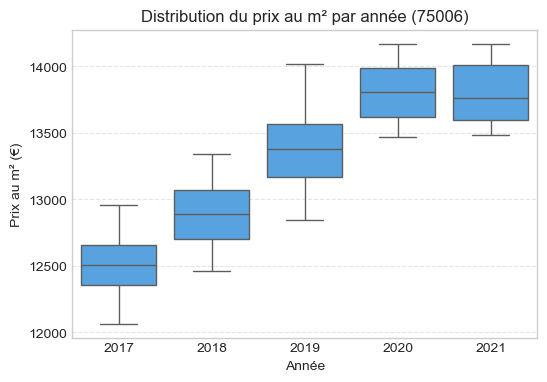

In [27]:
# Thomas : Proposition d'un graphique (bloxplot) pour mieux visualiser la corrélation etren le prix au m² et les années.

import seaborn as sns
plt.figure(figsize=(6,4))
sns.boxplot(x=subset["annee"], y=subset["prix_m2"], color="#42A5F5")
plt.title("Distribution du prix au m² par année (75006)")
plt.xlabel("Année")
plt.ylabel("Prix au m² (€)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

On observe un déplacement progressif de la distribution des prix au m² vers le haut au fil des années. 
La médiane augmente de manière continue, ce qui met en évidence une corrélation positive entre le temps et les prix immobiliers. 
Cette observation est confirmée par un coefficient de corrélation de Spearman élevé (0.898).

Regardons maintenant si le type de bien à une influence sur le prix au metre carré également.

### 10. Analyse des locaux industriels, commerciaux et assimilés 

In [28]:
#On crée un dataset qui ne contient que les locaux commerciaux

df_locaux_commerciaux = df[df["code_type_local"] == 4].copy()
    
 #On retire les colonnes qui sont à priori inutiles ET nous allons nous concentrer sur les appartements dans un premier temps

df_locaux_commerciaux = df_locaux_commerciaux.drop(columns=[
    "adresse_numero",
    "adresse_nom_voie",
    "code_type_local"
]).reset_index()

df_locaux_commerciaux["annee"] = df_locaux_commerciaux["date_mutation"].dt.year

df_locaux_commerciaux.head(5)

,index,date_mutation,valeur_fonciere,code_postal,nom_commune,type_local,surface_reelle,prix_m2,annee
0,18,2017-02-01,3 113 277.30,75003,Paris 3e Arrondissement,Local industriel. commercial ou assimilé,250,12 453.11,2017
1,29,2017-02-17,1 164 375.26,75003,Paris 3e Arrondissement,Local industriel. commercial ou assimilé,95,12 256.58,2017
2,34,2017-02-20,380 252.19,75003,Paris 3e Arrondissement,Local industriel. commercial ou assimilé,31,12 266.20,2017
3,91,2017-03-09,362 384.17,75001,Paris 1er Arrondissement,Local industriel. commercial ou assimilé,29,12 496.01,2017
4,109,2017-03-29,315 907.23,75003,Paris 3e Arrondissement,Local industriel. commercial ou assimilé,25,12 636.29,2017


In [29]:
#Préparons un dataframe en regroupant les prix au metre carré moyens des ventes par année
df_evolution_prix_au_m2 = df_locaux_commerciaux.groupby("annee")["prix_m2"].mean().reset_index()

df_evolution_prix_au_m2

,annee,prix_m2
0,2017,10 949.91
1,2018,11 569.50
2,2019,11 960.13
3,2020,11 966.47
4,2021,12 006.49


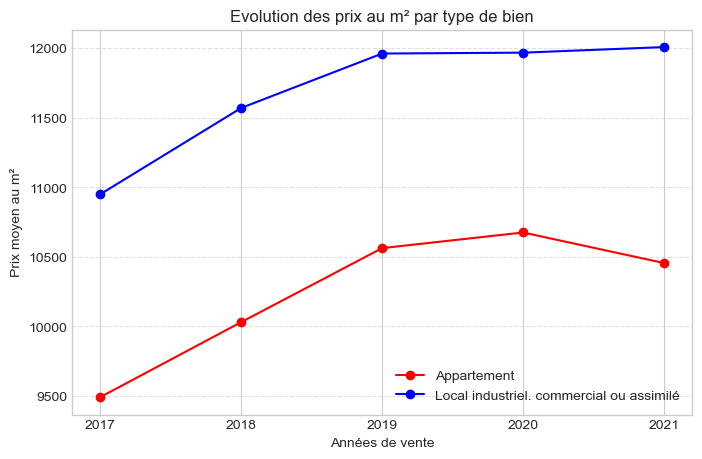

In [30]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
#1. Je reprends mon premier dataframe et groupe par année et par type de bien (pour ne pas mélanger les locaux commerciaux et les appartements).
df["annee"] = pd.to_datetime(df["date_mutation"]).dt.year
df_evolution = df.groupby(["annee","type_local"])["prix_m2"].mean().reset_index()

#2. Je fais mon graphique ↓
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

for type_bien in df_evolution["type_local"].unique():
    subset = df_evolution[df_evolution["type_local"] == type_bien]

# Attribution des couleurs
    if type_bien == "Appartement":
        couleur = "red"
    else:
        couleur = "blue"
        
    plt.plot(
        subset["annee"],
        subset["prix_m2"],
        marker="o",
        label=type_bien,
        color = couleur
    )

plt.xlabel('Années de vente')
plt.ylabel('Prix moyen au m²')
plt.title('Evolution des prix au m² par type de bien')
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(df_evolution["annee"].unique())
plt.show()

Le prix au metre carré des locaux commerciaux est ?
• suit l'évolution des prix sauf pour l'année 2021, les appartements on baissé mais pas les locaux industriels.
• le prix au m² des locaux commerciaux est plus élevé que pour les appartements.

Après ces analyses, nous pouvons conclure que les dimensions à utiliser pour prédire le prix au m² sont : 
- la surface du bien immobilier,
- la date considérée, 
- la localisation (code_postal), 
- le type de bien.

# Milestone 2 - Entraînement de l'algorithme

Dans cette section nous allons maintenant entrâiner un algorithme à prédire la valeur fonciere d'un bien immobilier. Pour cela nous allons utiliser l'algorithme de régression linéaire.

On commence par préparer nos données en transformant les colonnes catégoriques du code postal et du type de local grâce au one hot encoder (sklearn) / get_dummies (pandas)

In [31]:
# 1. On repart du dataset principal
df_modele = df.copy()

# 2. On s'assure que la date est bien au bon format
#df_modele["date_mutation"] = pd.to_datetime(df_modele["date_mutation"], errors="coerce")

# 3. On crée un timestamp 
df_modele["timestamp"]=df_modele['date_mutation'].astype('datetime64[s]').astype('int64') / 10**9

# 4. On garde seulement les colonnes utiles pour la prédiction
df_modele = df_modele[[
    "valeur_fonciere",
    "surface_reelle",
    "code_postal",
    "type_local",
    "timestamp"
]]

# 5. On supprime les lignes avec valeurs manquantes
df_modele = df_modele.dropna()


In [32]:
df_modele.head(20)

,valeur_fonciere,surface_reelle,code_postal,type_local,timestamp
0,550 559.68,50,75003,Appartement,1.48
1,1 576 492.46,163,75008,Appartement,1.48
2,657 757.36,66,75008,Appartement,1.48
3,250 086.82,22,75003,Appartement,1.48
4,176 266.71,15,75001,Appartement,1.48
5,384 552.23,39,75008,Appartement,1.48
6,754 263.18,75,75008,Appartement,1.48
7,1 166 410.98,117,75008,Appartement,1.48
8,360 917.99,33,75003,Appartement,1.48
9,425 134.60,38,75003,Appartement,1.49


In [33]:
# ici je fais le HOT-ONE-ENCODING, chaque code postal devient une colonne
# Drop_first = True pour éviter d'avoir 2 colonnes qui génèrerait une multicolinéarité, ce qui peut poser problème dans une regression linéaire.
df_modele = pd.get_dummies(df_modele, columns=["code_postal", "type_local"], drop_first=True)

On utilise le train_test_split pour prélever un tiers de nos données (33%) et les garder de côté. Nous allons entraîner notre algorithme sur le reste des données et puis mesurer notre erreur moyenne en pourcentage de la valeur foncière

In [34]:
# On sépare le jeu de données entre echantillons d'apprentissage et de test 
# La valeur y à trouver est la valeur foncière

from sklearn.model_selection import train_test_split
# train_test_split(...) coupe les données en 2 parties :
# • 67 % pour apprendre
# • 33 % pour tester

X = df_modele.drop("valeur_fonciere", axis=1)  # La colonne à expliquer
y = df_modele["valeur_fonciere"]   # La colonne à prédire

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [35]:
#conversion des données en str
# • Pour une régression linéaire, on ne veut justement pas convertir tout en texte.
# • Par contre on souhaite afficher les "True" et "False" par 1 ou 0"

X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# On entraîne l'algorithme et on effectue la prédiction
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

erreur = mean_absolute_percentage_error(y_test, y_pred) * 100  # Représente les erreurs observées dans l'échantillon de test entre la valeur de vente du bien (réelle) et la valeur prédite.
print("Erreur moyenne en pourcentage :", round(erreur, 2), "%")

Erreur moyenne en pourcentage : 9.53 %


#### Notre algorithme fait donc 9,53 % d'erreur en moyenne sur la prédiction de la valeur foncière.

Mes conclusions sur ce résultat et comment j'aurais pu aller plus loin :

- Le taux d'erreur induit qu'une prédiction sera fiable à 9,5% près, ce qui est satisfaisant.
  
- Les variables utilisées, notamment la surface, la localisation (code postal) et le type de bien, jouent un rôle déterminant dans l’explication du prix.
  
- Cependant, le modèle reste limité car il ne prend peut-être pas en compte certains facteurs importants influençant le prix immobilier comme l’état du bien, l’étage, l’exposition ou encore d'autres caractéristiques qui n'apparaitraient pas dans les données exploitées.
  
- Pour enrichir la précision des prédictions, il serait pertinent d'enrichir le jeu de données et peut-être remonter plus loin dans les années.

# Milestone 3 - Prédiction définitive pour le client 

Nous avons récupéré le fichier avec le portefeuille des actifs de la société. Nous allons l'importer puis effectuer la prédiction et statuer sur la branche qui, selon notre prédiction, aura le plus de valeur à la date demandée c'est à dire au 31 décembre 2022.<br>
Petite précision, nous souhaitons continuer à utiliser la surface réelle pour faire les calculs et pas la surface carrez. 

In [37]:
#On importe les données dans un dataframe
df_actifs = pd.read_excel(r"C:\Users\thoma\OneDrive\Bureau\OPENCLASSROOM\Livrables\Projet_8 - Réalisez une analyse de données en Python\portefeuille_actifs.xlsx")

import datetime as dt
df_actifs["timestamp"] = "2022-12-31"
df_actifs["timestamp"] = df_actifs["timestamp"].astype('datetime64[s]').astype('int64') / 10**9

# Le modèle ayant été entraîné avec une colonne "Surface réelle", je dois renommer "surface réelle bati"
df_actifs.rename(columns={
    "surface_reelle_bati": "surface_reelle"
}, inplace=True)


Nous avons la liste des biens immobiliers de l'entreprise. Pour effectuer une prédiction, nous devons mettre ce fichier au même format que le dataframe que nous avons utilisé lors de l'entraînement de l'algorithme.

In [38]:
# Thomas - Je vérifie le résultat de l'import
df_actifs.head()

,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle,nombre_pieces_principales,longitude,latitude,timestamp
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.35,48.86,1.67
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.36,48.87,1.67
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.36,48.86,1.67
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.30,48.87,1.67
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.31,48.88,1.67


In [39]:
# Thomas - Je contrôle que tout est bon (nb de lignes importées par exemple)
df_actifs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   adresse_numero             275 non-null    int64  
 1   adresse_nom_voie           275 non-null    object 
 2   code_postal                275 non-null    int64  
 3   code_commune               275 non-null    int64  
 4   nom_commune                275 non-null    object 
 5   surface_carrez             275 non-null    float64
 6   code_type_local            275 non-null    int64  
 7   type_local                 275 non-null    object 
 8   surface_reelle             275 non-null    int64  
 9   nombre_pieces_principales  275 non-null    int64  
 10  longitude                  275 non-null    float64
 11  latitude                   275 non-null    float64
 12  timestamp                  275 non-null    float64
dtypes: float64(4), int64(6), object(3)
memory usage: 2

In [40]:
# Thomas - je prépare mon dataframe
df_actifs_modele = df_actifs[[
    "code_postal",
    "surface_reelle",
    "type_local",
    "timestamp"
]].copy()

df_actifs.head()

,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle,nombre_pieces_principales,longitude,latitude,timestamp
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.35,48.86,1.67
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.36,48.87,1.67
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.36,48.86,1.67
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.30,48.87,1.67
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.31,48.88,1.67


In [41]:
#On réutilise les mêmes fonctions pour faire le one hot encoding des variables catégorielles

#1. One-hot encoding
df_actifs_modele = pd.get_dummies(
    df_actifs_modele,
    columns=["code_postal", "type_local"],
    drop_first=True
)

#2. Mettre le jeu de données exactement dans le même format que celui utilisé pour entraîner le modèle
# Le modèle ayant été entraîné sur des variables transformées via un encodage one-hot, 
# il est nécessaire d’appliquer les mêmes transformations au nouveau dataset et de réaligner les colonnes 
# afin de garantir la cohérence des prédictions.
df_actifs_modele = df_actifs_modele.reindex(columns=X_train.columns, fill_value=0)

#On importe la librairie datetime pour pouvoir créer une colonne timestamp avec la date du 31 décembre 2022 pour la prédiction
#Thomas - Fait dès le début de l'exercice.


In [42]:
#Conversion du dataframe en str
df_actifs_modele = df_actifs_modele.astype(float)


Notre dataframe est prêt à être utilisé par notre algorithme de prédiction.

In [43]:
#On effectue la prédiction
df_actifs["prediction"] = model.predict(df_actifs_modele)

#On vérifie les 10 premières valeurs
df_actifs.head(10)

# Je créé un nouveau Dataframe df_actifs car df_actifs_modele ne me sert que pour le modèle de prédiction, pas pour de l'affichage.

,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle,nombre_pieces_principales,longitude,latitude,timestamp,prediction
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.35,48.86,1.67,431 444.35
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.36,48.87,1.67,368 861.39
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.36,48.86,1.67,827 086.36
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.30,48.87,1.67,878 984.85
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.31,48.88,1.67,324 852.33
5,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,33.40,2,Appartement,35,1,2.31,48.88,1.67,463 385.46
6,52,RUE DES GRAVILLIERS,75003,75103,Paris 3e Arrondissement,21.35,2,Appartement,24,2,2.36,48.86,1.67,390 174.18
7,208,RUE SAINT MAUR,75010,75110,Paris 10e Arrondissement,54.69,2,Appartement,60,3,2.37,48.87,1.67,642 454.13
8,142,RUE DE COURCELLES,75017,75117,Paris 17e Arrondissement,9.30,2,Appartement,11,1,2.30,48.88,1.67,139 736.78
9,52,RUE LAMARCK,75018,75118,Paris 18e Arrondissement,12.88,2,Appartement,13,1,2.34,48.89,1.67,141 906.87


Maintenant nous allons comparer la valorisation prédite pour les deux segments.

In [44]:
# Segment sur les appartements
particuliers = df_actifs[df_actifs["type_local"] == "Appartement"]
val_particuliers = particuliers["prediction"].sum() / 1_000_000


# Segment sur les locaux commerciaux
locaux_commerciaux = df_actifs[df_actifs["type_local"] != "Appartement"]
val_locaux_commerciaux = locaux_commerciaux["prediction"].sum() / 1_000_000


In [45]:
plt.figure(figsize=(6,4))

bars = plt.bar(labels, valeurs)

# Mise en avant du plus élevé
bars[1].set_alpha(0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.1f} M€",
             ha='center', va='bottom', fontsize=11)

plt.title("Valorisation par type de bien (M€)", fontsize=13)
plt.ylabel("Millions d'euros")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

NameError: name 'labels' is not defined

<Figure size 600x400 with 0 Axes>

In [ ]:
#Valorisation du portefeuille sur le segment des particuliers
print("la valorisation du segment particulier est (en millions euros):", round(val_particuliers,2))


In [ ]:
#Valorisation du portefeuille sur le segment corporate
print("la valorisation du segment corporate est (en millions euros):", round(val_locaux_commerciaux,2))


Mes conclusions sur le segment avec la plus grande valorisation et sur les limites de cette estimation :

- Il subsite un taux d'erreur de 9,5% ce qui représente tout de même 16,06 Millions.

- Les appartements valent 71 M, les locaux commerciaux & assimilés valent 97,97 Millions.

- dans les 26 Millions d'écart subsiste 10% d'erreur.
  
- Cette estimation reste approximative car elle repose sur un modèle de régression linéaire simplifié et sur un nombre limité de variables explicatives.

# Milestone 4 - Classification des données issues du jeu de test

Dans cette partie nous allons labelliser automatiquement les biens immobiliers comme étant :
- soit des Appartements
- soit des Local industriel. commercial ou assimilé
Pour cela nous allons utiliser l'algorithme du KMeans sur le jeu de données partagé par l'entreprise.

Pour que l'algorithme fonctionne, il faut que nous préparions les données en supprimant les dimensions inutiles et en nous concentrant sur le facteur discriminant entre les appartements et les locaux commerciaux : la différence dans le prix au mètre carré tel que nous l'avons vu avant.

In [ ]:
#On importe les données dans un dataframe
df_actifs_immobiliers = pd.read_excel(r"C:\Users\thoma\OneDrive\Bureau\OPENCLASSROOM\Livrables\Projet_8 - Réalisez une analyse de données en Python\echantillon_a_classer.xlsx")

On applique les transformations nécessaires. Tout d'abord nous allons calculer le prix au mètre carré en divisant la valeur foncière par la surface. Ensuite nous allons retirer ces colonnes car nous avons déjà l'information qu'elles contiennent dans la dimension prix au mètre carré désormais.

Enfin toutes nos données sont de l'année 2021. Nous allons retirer cette dimension qui ne devrait pas être discriminante dans le regroupement des données.

In [ ]:
# Création de la colonne "Prix au M²"
df_actifs_immobiliers["prix_m2"] = df_actifs_immobiliers["valeur_fonciere"] / df_actifs_immobiliers["surface_reelle"]

# Je crée un Dataframe dans lequel il n'y  aura que le prix au m². 
df_kmeans = df_actifs_immobiliers[["prix_m2"]].copy()

df_kmeans

Nous observons dans les données que nous avons des valeurs différentes de prix au mètre carré pour un même arrondissement (ici le 19ème arrondissement). Il se peut fort que cela soit notre dimension à utiliser pour attribuer les prix au mètre carré les plus élévé dans un département aux locaux commerciaux, et les prix les plus bas aux appartements.

Pour effectuer cette opération, nous allons utiliser l'algorithme du Kmeans qui va rechercher 2 centroïdes à travers les données.

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)

X_kmeans = df_kmeans[["prix_m2"]]
df_kmeans["cluster"] = kmeans.fit_predict(X_kmeans)

moyennes_clusters = df_kmeans.groupby("cluster")["prix_m2"].mean()
print(moyennes_clusters)

df_kmeans["type_pred"] = df_kmeans["cluster"].map({
    0: "Appartement",
    1: "Local industriel, commercial ou assimilé"
})


In [ ]:
# On vérifie les données de la prédiction
df_kmeans[["prix_m2","type_pred"]].head(100)

Nous avons obtenu notre prédiction. Nous pouvons changer les labels et remplacer les valeurs à 0 par Local industriel. commercial ou assimilé et les valeurs à +1 par Appartement. 

In [ ]:
#On affiche les résultats
df_kmeans.groupby("type_pred")["prix_m2"].agg(["count", "mean", "min", "max"])

# Milestone 5 - Analyse et présentation des résultats

Mes conclusions sur l'analyse et les limites de l'exercice :

L’algorithme KMeans a séparé automatiquement les biens en deux groupes à partir du seul prix au m². Le premier groupe présente un prix moyen au m² plus faible et a été interprété comme correspondant aux appartements. Le second groupe présente un prix moyen au m² plus élevé et a été interprété comme correspondant aux locaux commerciaux.

J’ai interprété les clusters en comparant leurs moyennes de prix au m², puis j’ai attribué un label métier à chaque groupe.

Vérifier si tous les critères qui ont un impact sur la valeur fonçière sont bien présentes dans les jeux de données.